# T66 — Subducted-slab flux inventory

**Cluster F: Mantle dynamics.**

Every year Earth subducts ~3 km² of oceanic lithosphere per second — a plate-tectonic budget item whose absolute value has changed by factors of 2-3 across the Phanerozoic. Deep-time compilations of *what* has been subducted (slab volume, slab age, sediment volume, carbonate mass, water mass) are the currency of most whole-Earth geochemical cycle papers (Dutkiewicz et al. sediment/carbon, Dixon et al. water, Merdith & Müller pySCION). This notebook builds the underlying plumbing — extract subduction zones at each time snapshot, sample the paleo age grid at each trench point, weight by convergence rate, integrate to a global total.

## What this notebook produces

1. **§3 — SZ tessellation at one age.** `PlateReconstruction.tessellate_subduction_zones` gives one row per trench-segment midpoint with convergence rate, obliquity, trench-normal azimuth, subducting plate ID, over-riding plate ID, and (via age-grid sampling) subducting-slab age.
2. **§4 — Trench map at the target age.** All SZ points on the paleo-Earth, coloured by subducted-slab age. Cool colours = young hot slab (Cordilleran arcs); warm colours = old cold slab (western Pacific).
3. **§5 — Global-integrated flux time series.** Loop over 5-Myr snapshots 0-100 Ma. At each snapshot: total convergent trench length, mean subducted-slab age, area flux (km²/yr = Σ convergence × trench-length), and a proxy volume-flux (area × slab-thickness = f(age) via a plate-cooling model).

## Learning objectives

- Call `PlateReconstruction.tessellate_subduction_zones` and interpret its output columns.
- Sample a paleo age grid at each trench point (subducting-slab age).
- Compute per-trench-length area flux from convergence rate + segment length.
- Estimate slab thickness from a plate-cooling model to convert area flux → volume flux.
- Integrate globally and plot as a time series.

## Prerequisites and runtime

- Uses only Z22 topologies + Z22 seafloor-age grid via `plate_model_manager`. No bundled data.
- Python: `gplately`, `pygplates`, `pygmt`, `pandas`, `numpy`, `matplotlib`, `xarray`, `netCDF4`.
- Runtime: ~90 s (dominated by age-grid loading in the §5 loop; SZ tessellation itself is fast).


## Environment + imports


In [1]:
from pathlib import Path
import os, sys
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr
import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, pygmt, gplately, pygplates, xr):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


Environment
  python      3.12.5
  numpy       2.3.2
  pandas      2.2.3
  pygmt       v0.18.0
  gplately    2.0.0.post19+git.2cce7bb3
  pygplates   1.0.0
  xarray      2026.4.0


In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME             = "Zahirovic2022"
ANCHOR_PLATE_ID        = 0                    # mantle frame — fine for kinematics

# Single-snapshot analysis (§3 + §4)
RECONSTRUCTION_TIME    = 20.0                 # Ma; deep Miocene, ~modern SZ geometry

# Time-series loop (§5)
FLUX_TIME_MIN_MA       = 0
FLUX_TIME_MAX_MA       = 100
FLUX_TIME_STEP_MA      = 5

# SZ tessellation cadence (km) — coarser = faster, finer = more accurate line lengths
TESSELLATE_KM          = 20.0

# Plate cooling model — Stein & Stein 1992 GDH1, used to turn slab age into
# thermal (mantle-lithosphere) thickness. slab-column thickness = crust (7 km)
# + mantle lithosphere from age.
def slab_thickness_km(age_ma):
    """Total slab thickness (crust + thermal boundary layer) in km, GDH1."""
    crust_km = 7.0                               # typical oceanic crust
    # GDH1 mantle-lithosphere thickness (Turcotte & Schubert convention)
    # h_TBL = 2.32 * sqrt(kappa * age) with kappa ~ 1e-6 m²/s
    kappa = 1e-6                                 # m²/s
    age_s = np.asarray(age_ma) * 1e6 * 365.25 * 86400
    h_tbl_m = 2.32 * np.sqrt(kappa * age_s)
    return crust_km + h_tbl_m / 1000.0

# Map layout
REGION, PROJ           = [-180, 180, -90, 90], "N15c"
# ============================================================================
print(f"  model:              {MODEL_NAME}")
print(f"  anchor:             {ANCHOR_PLATE_ID}")
print(f"  snapshot time:      {RECONSTRUCTION_TIME} Ma")
print(f"  flux loop:          {FLUX_TIME_MIN_MA}-{FLUX_TIME_MAX_MA} Ma at "
      f"{FLUX_TIME_STEP_MA}-Myr cadence")
print(f"  SZ tessellation:    {TESSELLATE_KM} km")
print(f"  Slab thickness @ 20 Ma:  {slab_thickness_km(20):.1f} km")
print(f"  Slab thickness @ 80 Ma:  {slab_thickness_km(80):.1f} km")
print(f"  Slab thickness @ 150 Ma: {slab_thickness_km(150):.1f} km")


  model:              Zahirovic2022
  anchor:             0
  snapshot time:      20.0 Ma
  flux loop:          0-100 Ma at 5-Myr cadence
  SZ tessellation:    20.0 km
  Slab thickness @ 20 Ma:  65.3 km
  Slab thickness @ 80 Ma:  123.6 km
  Slab thickness @ 150 Ma: 166.6 km


## 1. Load the plate model


In [3]:
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="data/pmm_cache")

recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_layer("Coastlines"),
    plot_engine=gplately.PygmtPlotEngine(),
    continents=model.get_layer("ContinentalPolygons"),
    time=RECONSTRUCTION_TIME,
    anchor_plate_id=ANCHOR_PLATE_ID,
)
print(f"  {MODEL_NAME} loaded")


  Zahirovic2022 loaded


## 2. SZ tessellation + slab-age sampling at the target snapshot

`PlateReconstruction.tessellate_subduction_zones` returns one row per trench-segment midpoint at the target age with columns:

- **lon, lat** — trench point
- **conv_rate_cm_per_yr** — orthogonal convergence rate (positive = convergent)
- **conv_obliquity** — angle between convergence vector and trench-normal
- **trench_normal_azimuth**
- **subducting_plate_id, overriding_plate_id**
- **segment_length_arc** — length of the trench segment this point represents

We then sample the paleo seafloor-age grid at each (lon, lat) to get the subducting-slab age at that point.


In [4]:
sz_df = pd.DataFrame(recon.tessellate_subduction_zones(
    time=RECONSTRUCTION_TIME, tessellation_threshold_radians=np.radians(TESSELLATE_KM / 111.0),
    anchor_plate_id=ANCHOR_PLATE_ID),
    columns=["lon", "lat", "conv_rate_cm_per_yr", "conv_obliquity_deg",
             "migr_velocity_cm_per_yr", "migr_obliquity_deg",
             "segment_length_arc_deg", "trench_normal_azimuth_deg",
             "subducting_plate_id", "overriding_plate_id"])

# Retain only convergent segments (drop the flat-transform / divergent artefacts)
sz_df = sz_df[sz_df["conv_rate_cm_per_yr"] > 0].copy()

# Load the paleo seafloor-age grid at this time
age_grid_path = model.get_raster("AgeGrids", RECONSTRUCTION_TIME)
age_grid = xr.open_dataarray(age_grid_path)
# Standardise coord names
if "lon" not in age_grid.coords and "longitude" in age_grid.coords:
    age_grid = age_grid.rename({"longitude": "lon", "latitude": "lat"})

# Sample slab age at each SZ point (nearest-neighbour)
sz_df["slab_age_ma"] = age_grid.interp(
    lon=xr.DataArray(sz_df["lon"].values, dims="pt"),
    lat=xr.DataArray(sz_df["lat"].values, dims="pt"),
    method="nearest",
).values

# Convert segment length from arc degrees to km
sz_df["segment_length_km"] = sz_df["segment_length_arc_deg"] * 111.19
print(f"  {len(sz_df)} convergent SZ segment points at {RECONSTRUCTION_TIME:.0f} Ma")
print(f"  total convergent trench length: {sz_df['segment_length_km'].sum():,.0f} km")
print(f"  mean slab age: {sz_df['slab_age_ma'].dropna().mean():.1f} Ma")
print(f"  mean convergence rate: {sz_df['conv_rate_cm_per_yr'].mean():.2f} cm/yr")


  3181 convergent SZ segment points at 20 Ma
  total convergent trench length: 63,391 km
  mean slab age: 60.9 Ma
  mean convergence rate: 7.07 cm/yr


## 3. Trench map — SZ points on paleo-Earth, coloured by slab age


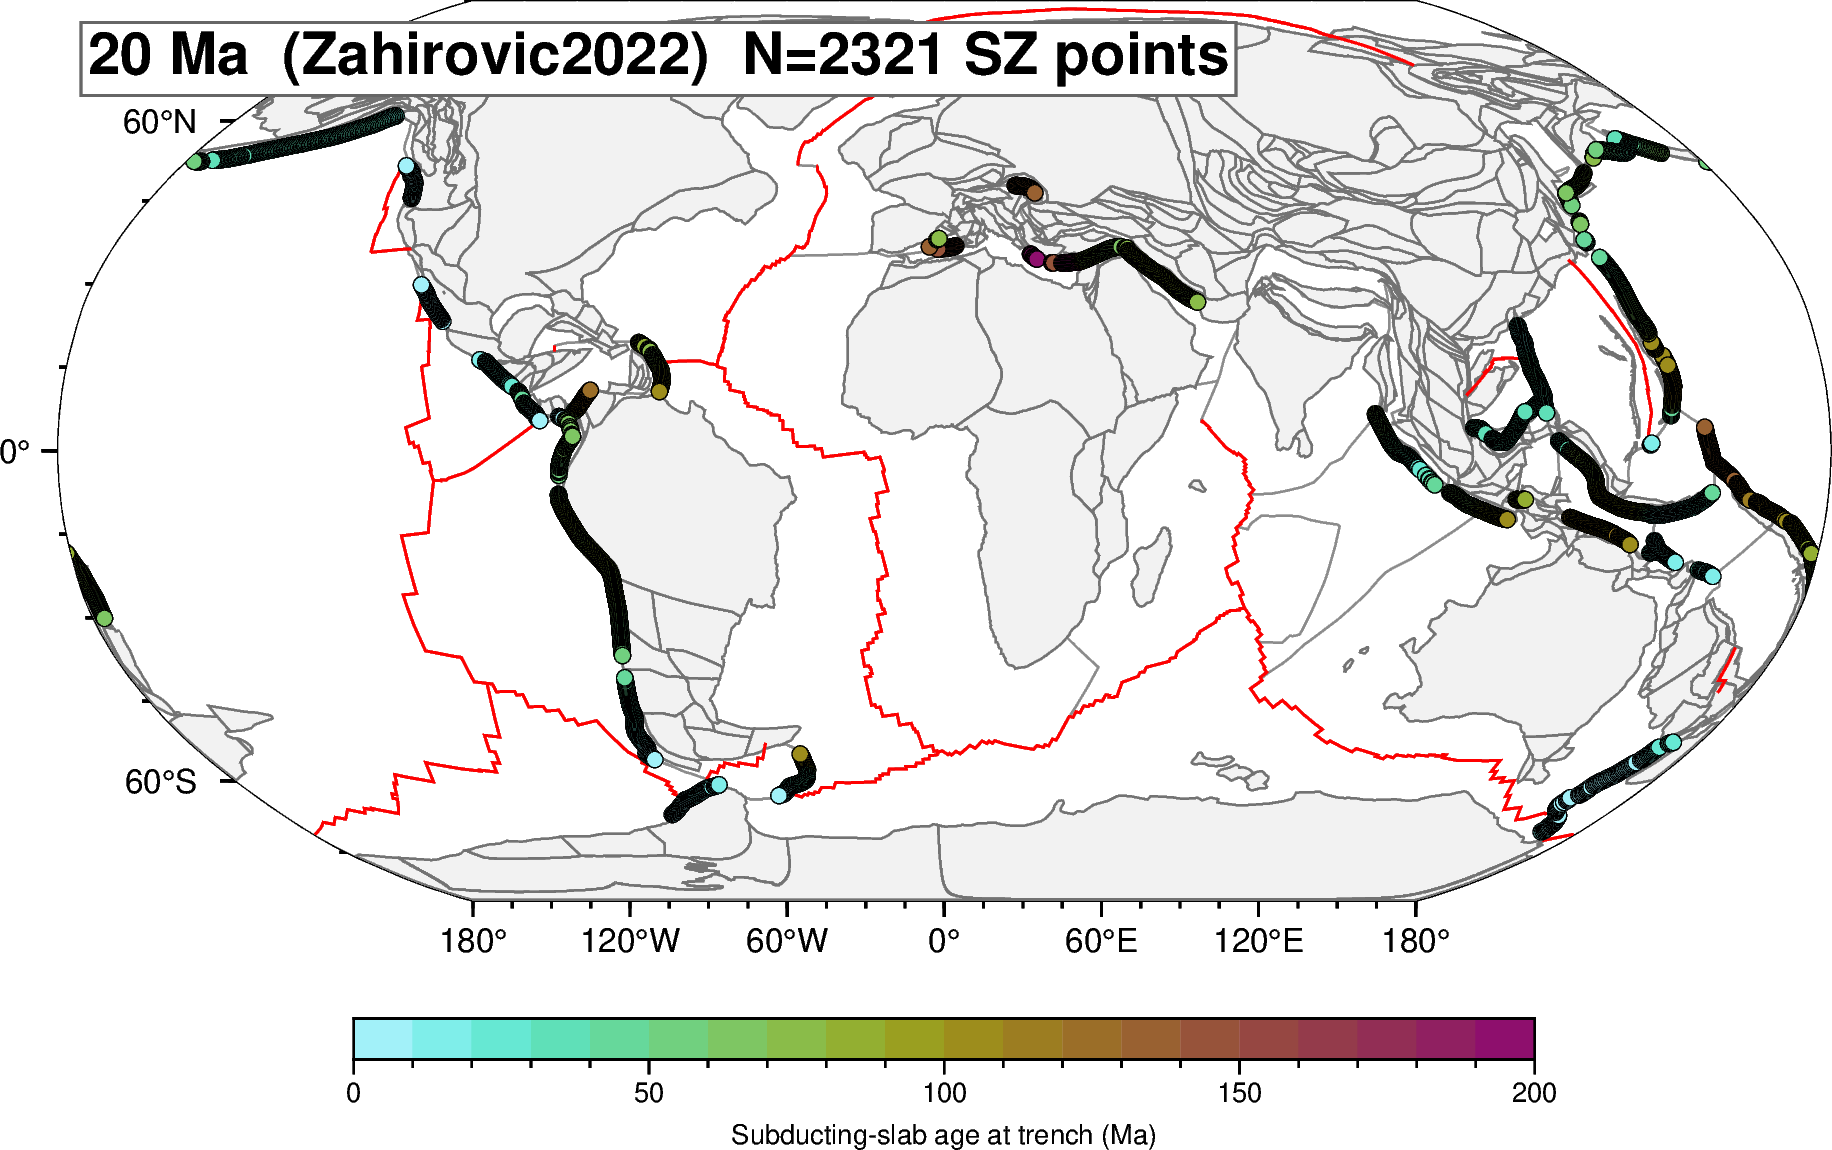

In [5]:
fig = pygmt.Figure()
gplot.time = RECONSTRUCTION_TIME
fig.basemap(region=REGION, projection=PROJ, frame="af")
fig.coast(region=REGION, projection=PROJ, water="white", shorelines=None)
try:
    # (engine now dispatched via gplately.PygmtPlotEngine on PlotTopologies)
    gplot.plot_all_topological_sections(fig, pen="0.5p,gray55")
    gplot.plot_continents(fig, fill="gray95", pen="0.5p,gray45")
    gplot.plot_ridges(fig, pen="0.6p,red")
except Exception:
    pass

# SZ points coloured by slab age.
# NOTE: pyGMT's fill= expects a colour STRING, not an array. To colour each
# symbol by a per-point value, pass the values as the third column of a
# (x, y, z) data matrix and let GMT read them through cmap=True. Passing
# fill=<pandas Series> here silently makes every symbol black.
sz_valid = sz_df.dropna(subset=["slab_age_ma"]).copy()
# Clip to CPT range so no point falls outside [0, 200] Ma and picks up an
# out-of-range colour.
sz_valid["slab_age_clipped"] = sz_valid["slab_age_ma"].clip(0, 200)

pygmt.makecpt(cmap="hawaii", series=[0, 200, 10], reverse=True)
fig.plot(
    x=sz_valid["lon"].values,
    y=sz_valid["lat"].values,
    style="c0.14c",
    fill=sz_valid["slab_age_clipped"].values,
    cmap=True,
    pen="0.2p,black",
    region=REGION,
    projection=PROJ,
)

fig.colorbar(position="JBC+w10c/0.35c+h+o0/1c",
             frame=["a50f10", "x+lSubducting-slab age at trench (Ma)"])
fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME})  N={len(sz_valid)} SZ points",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1000)


### How to read the trench map

- **Yellow-white points (young slab, < 30 Ma)** — Cordilleran-style young-slab arcs (Andes, Central America, Cascadia, New Guinea, some Kamchatka).
- **Dark red-brown points (old slab, > 100 Ma)** — cold-slab arcs (western Pacific: Marianas, Tonga-Kermadec, Aleutians, Japan). These are where the deepest earthquakes and most extensive slab-graveyards develop in the lower mantle.
- **The mean slab age at 20 Ma** should be ~65-75 Ma — this is Earth's characteristic value. If your global mean is dramatically different, either the age grid failed to load or the SZ filter is picking up spurious segments.


## 4. Global-integrated flux time series

For each snapshot 0-100 Ma at 5-Myr cadence: total convergent trench length, mean slab age, area flux (Σ convergence × segment length), and volume flux (area × slab thickness from GDH1).


In [6]:
def integrate_flux_at_time(t_ma):
    """Return dict of global-integrated SZ metrics at time t_ma."""
    try:
        sz = pd.DataFrame(recon.tessellate_subduction_zones(
            time=t_ma, tessellation_threshold_radians=np.radians(TESSELLATE_KM / 111.0),
            anchor_plate_id=ANCHOR_PLATE_ID),
            columns=["lon", "lat", "conv_rate_cm_per_yr", "conv_obliquity_deg",
                     "migr_velocity_cm_per_yr", "migr_obliquity_deg",
                     "segment_length_arc_deg", "trench_normal_azimuth_deg",
                     "subducting_plate_id", "overriding_plate_id"])
    except Exception:
        return None
    sz = sz[sz["conv_rate_cm_per_yr"] > 0].copy()
    if len(sz) == 0: return None
    try:
        age_grid_path = model.get_raster("AgeGrids", t_ma)
        ag = xr.open_dataarray(age_grid_path)
        if "lon" not in ag.coords and "longitude" in ag.coords:
            ag = ag.rename({"longitude": "lon", "latitude": "lat"})
        sz["slab_age_ma"] = ag.interp(
            lon=xr.DataArray(sz["lon"].values, dims="pt"),
            lat=xr.DataArray(sz["lat"].values, dims="pt"),
            method="nearest").values
    except Exception:
        sz["slab_age_ma"] = np.nan
    sz["segment_length_km"] = sz["segment_length_arc_deg"] * 111.19
    # Area flux per segment (km²/yr) = convergence rate (km/yr) × segment length (km)
    sz["area_flux_km2_per_yr"] = (sz["conv_rate_cm_per_yr"] * 1e-5) * sz["segment_length_km"]
    # Volume flux (km³/yr) = area flux × slab thickness (km)
    sz["slab_thickness_km"] = slab_thickness_km(sz["slab_age_ma"].fillna(sz["slab_age_ma"].mean() or 80))
    sz["volume_flux_km3_per_yr"] = sz["area_flux_km2_per_yr"] * sz["slab_thickness_km"]
    return {
        "time_ma": t_ma,
        "total_trench_length_km": sz["segment_length_km"].sum(),
        "mean_slab_age_ma":       sz["slab_age_ma"].dropna().mean(),
        "mean_conv_rate_cm_yr":   sz["conv_rate_cm_per_yr"].mean(),
        "total_area_flux_km2_yr": sz["area_flux_km2_per_yr"].sum(),
        "total_vol_flux_km3_yr":  sz["volume_flux_km3_per_yr"].sum(),
    }

flux_records = []
for t in range(FLUX_TIME_MIN_MA, FLUX_TIME_MAX_MA + FLUX_TIME_STEP_MA, FLUX_TIME_STEP_MA):
    rec = integrate_flux_at_time(float(t))
    if rec is not None:
        flux_records.append(rec)
        print(f"  {t:>3d} Ma: L={rec['total_trench_length_km']:>8,.0f} km   "
              f"<age>={rec['mean_slab_age_ma']:>5.1f} Ma   "
              f"area={rec['total_area_flux_km2_yr']:.2f} km²/yr   "
              f"vol={rec['total_vol_flux_km3_yr']:.2f} km³/yr")

flux_df = pd.DataFrame(flux_records)


    0 Ma: L=  64,406 km   <age>= 66.1 Ma   area=3.16 km²/yr   vol=342.00 km³/yr
    5 Ma: L=  61,922 km   <age>= 68.3 Ma   area=3.82 km²/yr   vol=411.93 km³/yr
   10 Ma: L=  61,343 km   <age>= 68.7 Ma   area=3.67 km²/yr   vol=393.39 km³/yr
   15 Ma: L=  61,764 km   <age>= 64.8 Ma   area=4.11 km²/yr   vol=428.08 km³/yr
   20 Ma: L=  63,391 km   <age>= 60.9 Ma   area=4.48 km²/yr   vol=466.42 km³/yr
   25 Ma: L=  58,241 km   <age>= 57.8 Ma   area=4.73 km²/yr   vol=499.24 km³/yr
   30 Ma: L=  61,444 km   <age>= 54.1 Ma   area=4.31 km²/yr   vol=435.62 km³/yr
   35 Ma: L=  64,069 km   <age>= 51.6 Ma   area=4.84 km²/yr   vol=473.96 km³/yr
   40 Ma: L=  61,976 km   <age>= 51.4 Ma   area=4.29 km²/yr   vol=407.58 km³/yr
   45 Ma: L=  58,509 km   <age>= 47.7 Ma   area=3.88 km²/yr   vol=350.70 km³/yr
   50 Ma: L=  64,722 km   <age>= 41.3 Ma   area=4.61 km²/yr   vol=387.00 km³/yr
   55 Ma: L=  66,575 km   <age>= 41.1 Ma   area=5.10 km²/yr   vol=425.99 km³/yr
   60 Ma: L=  63,598 km   <age>= 43.2 Ma

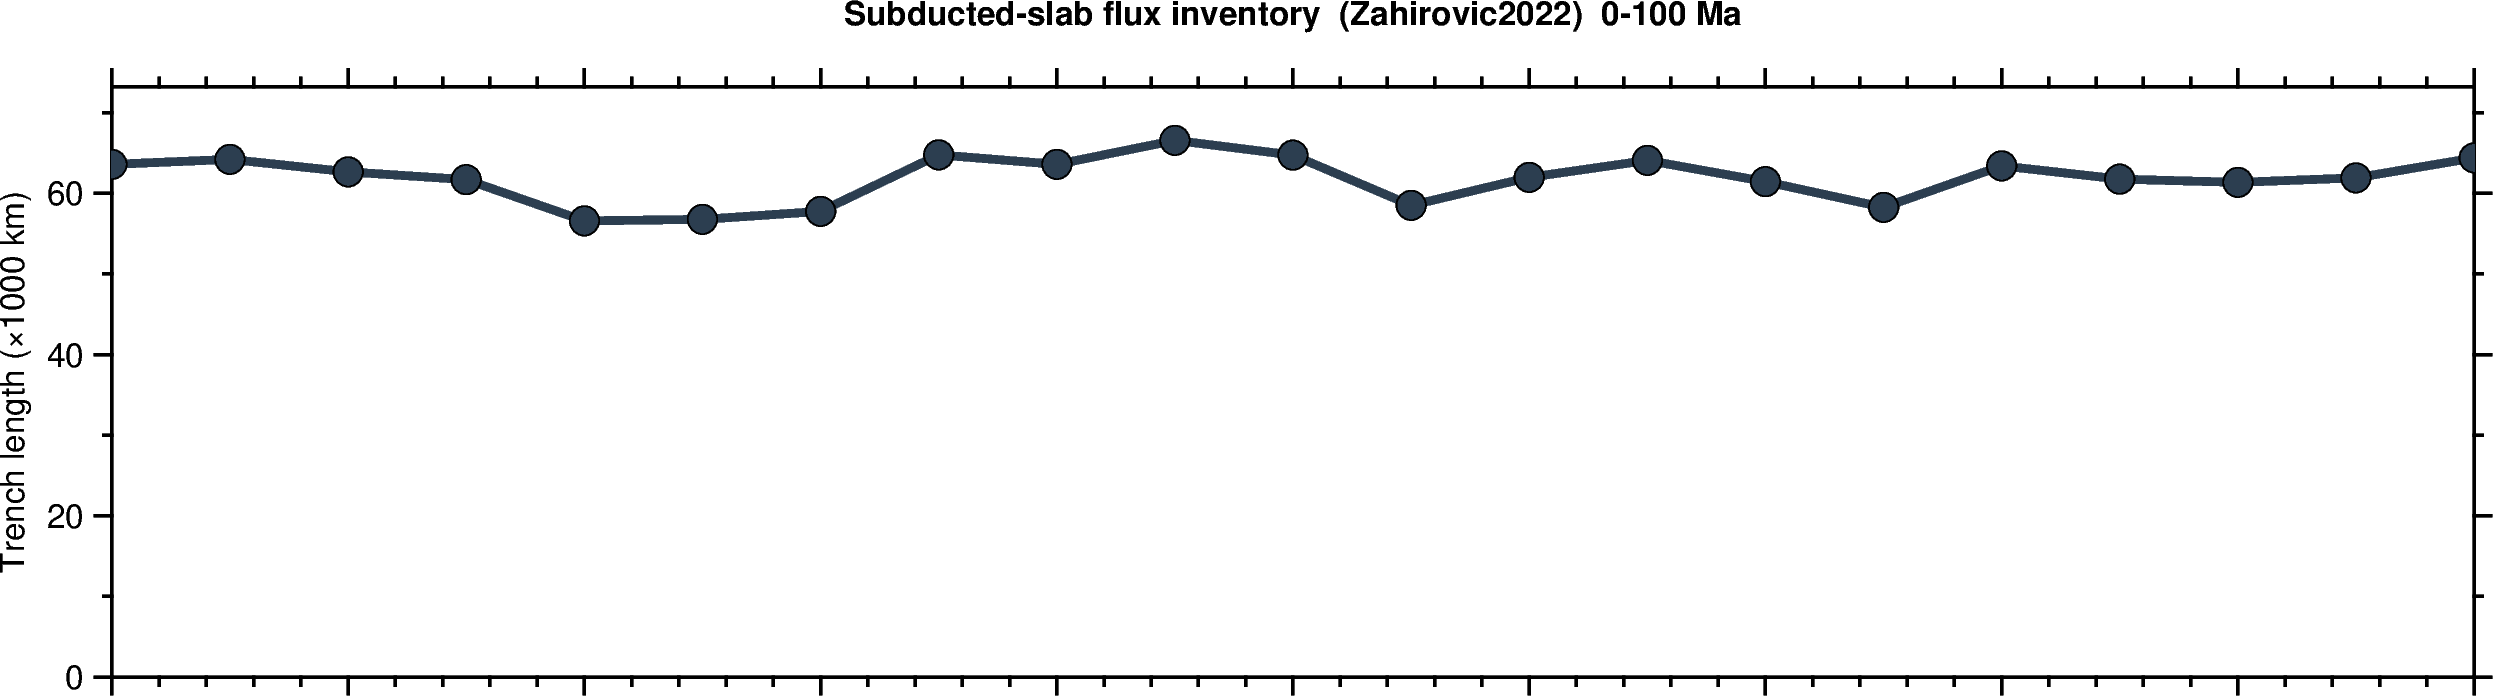

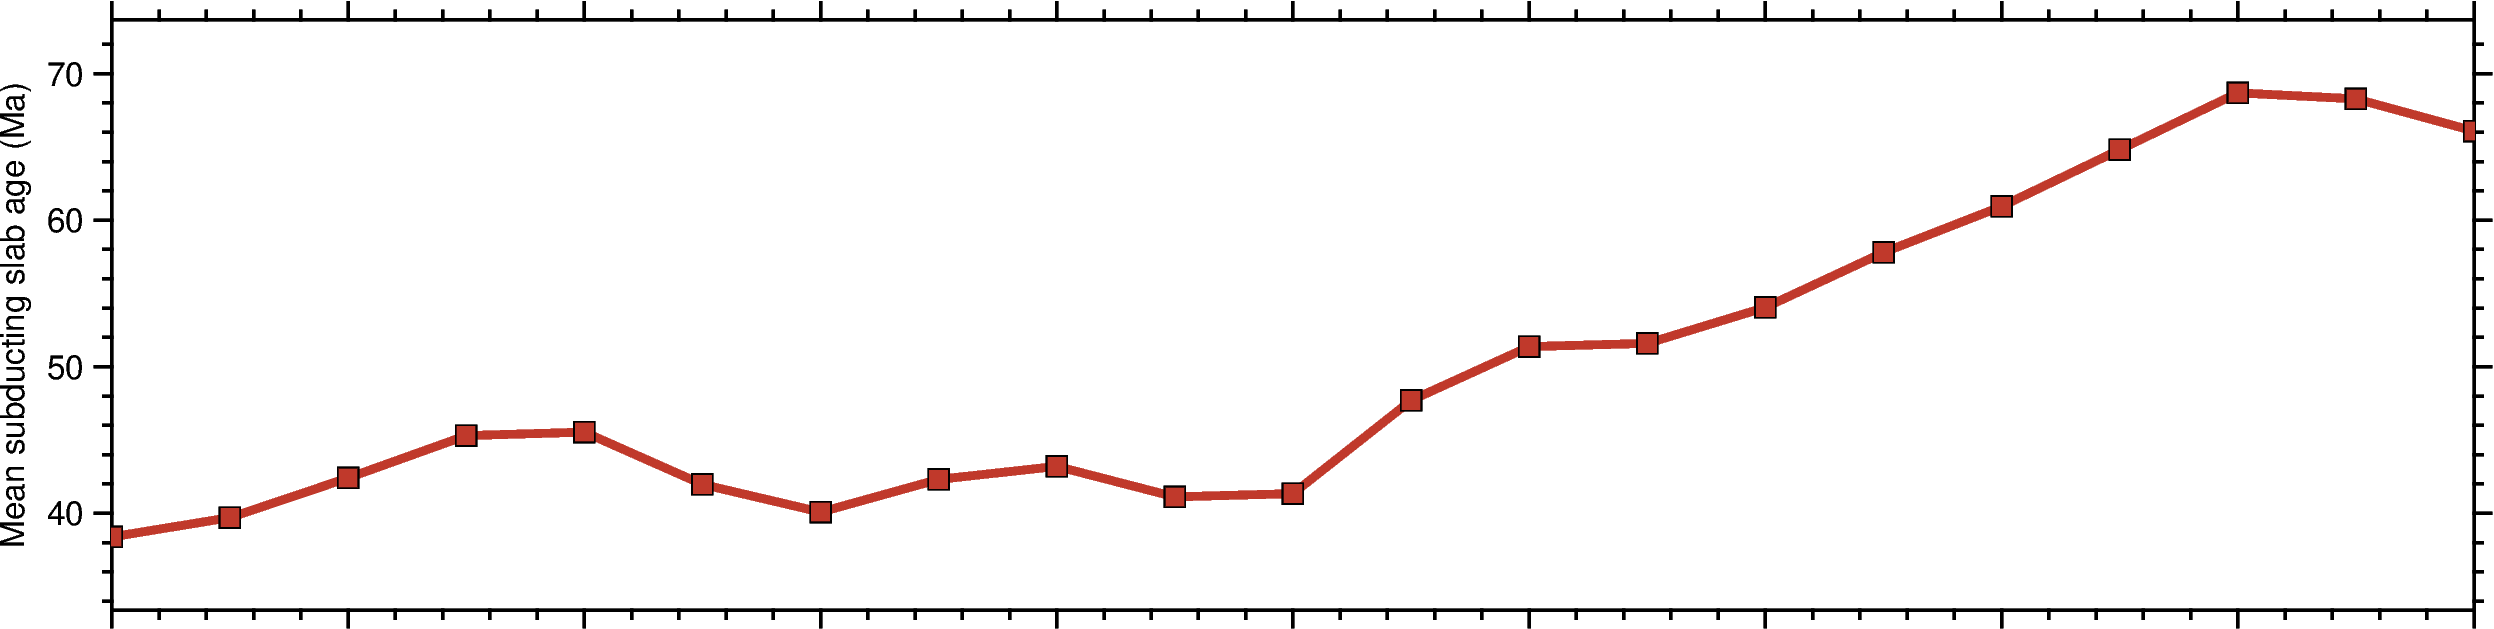

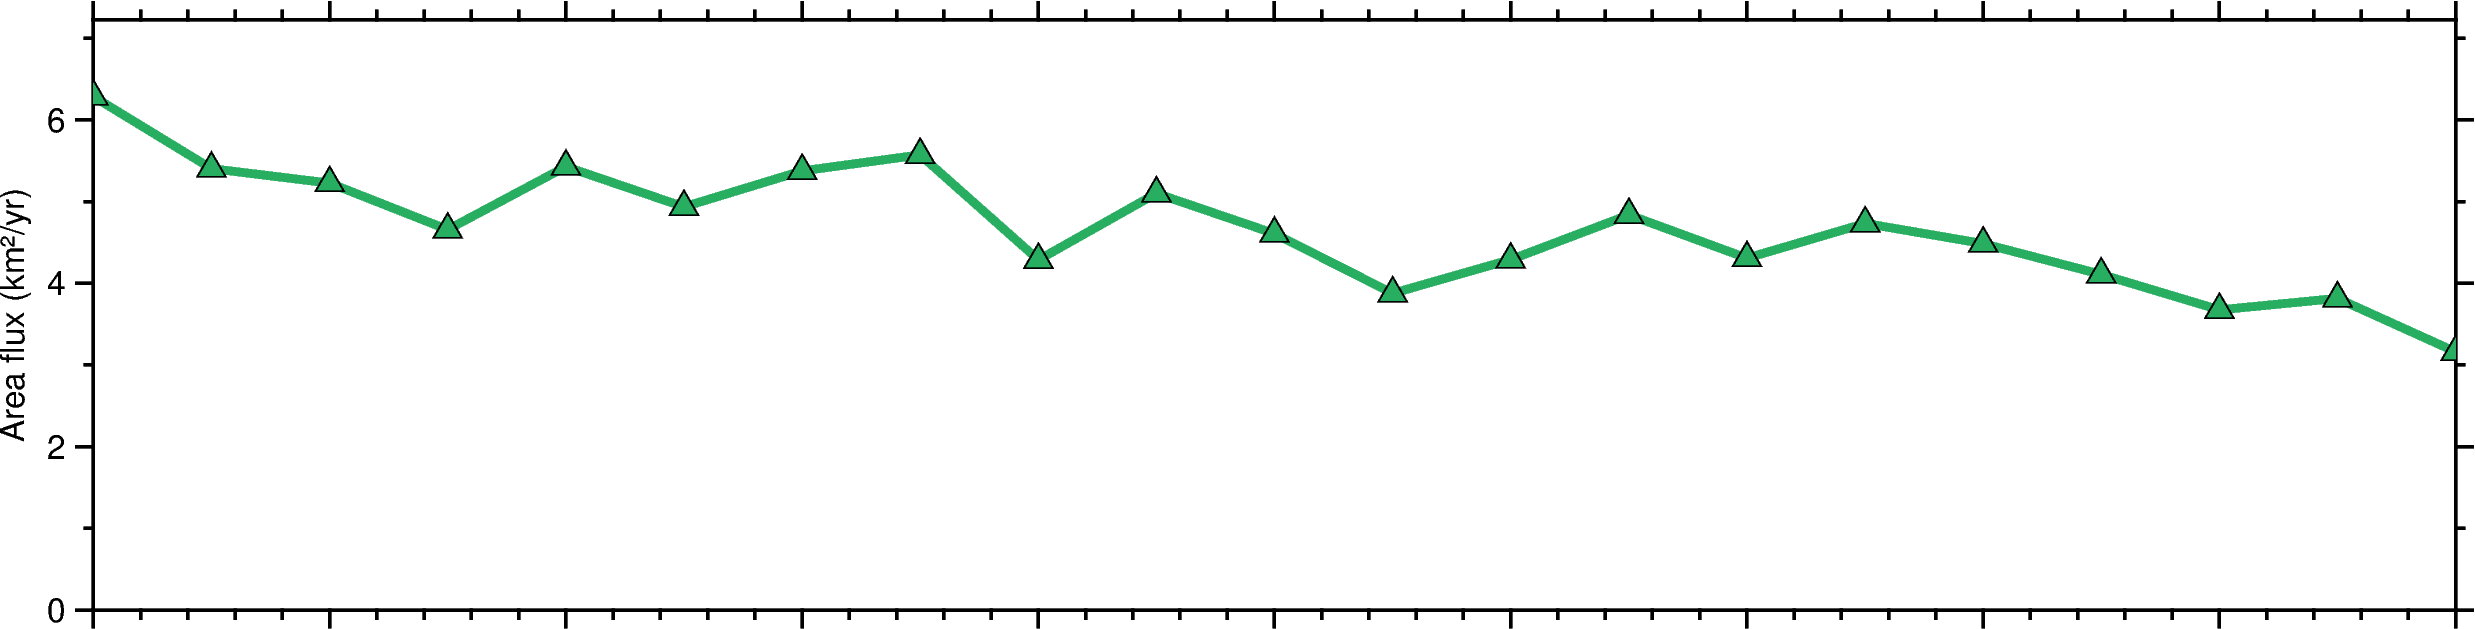

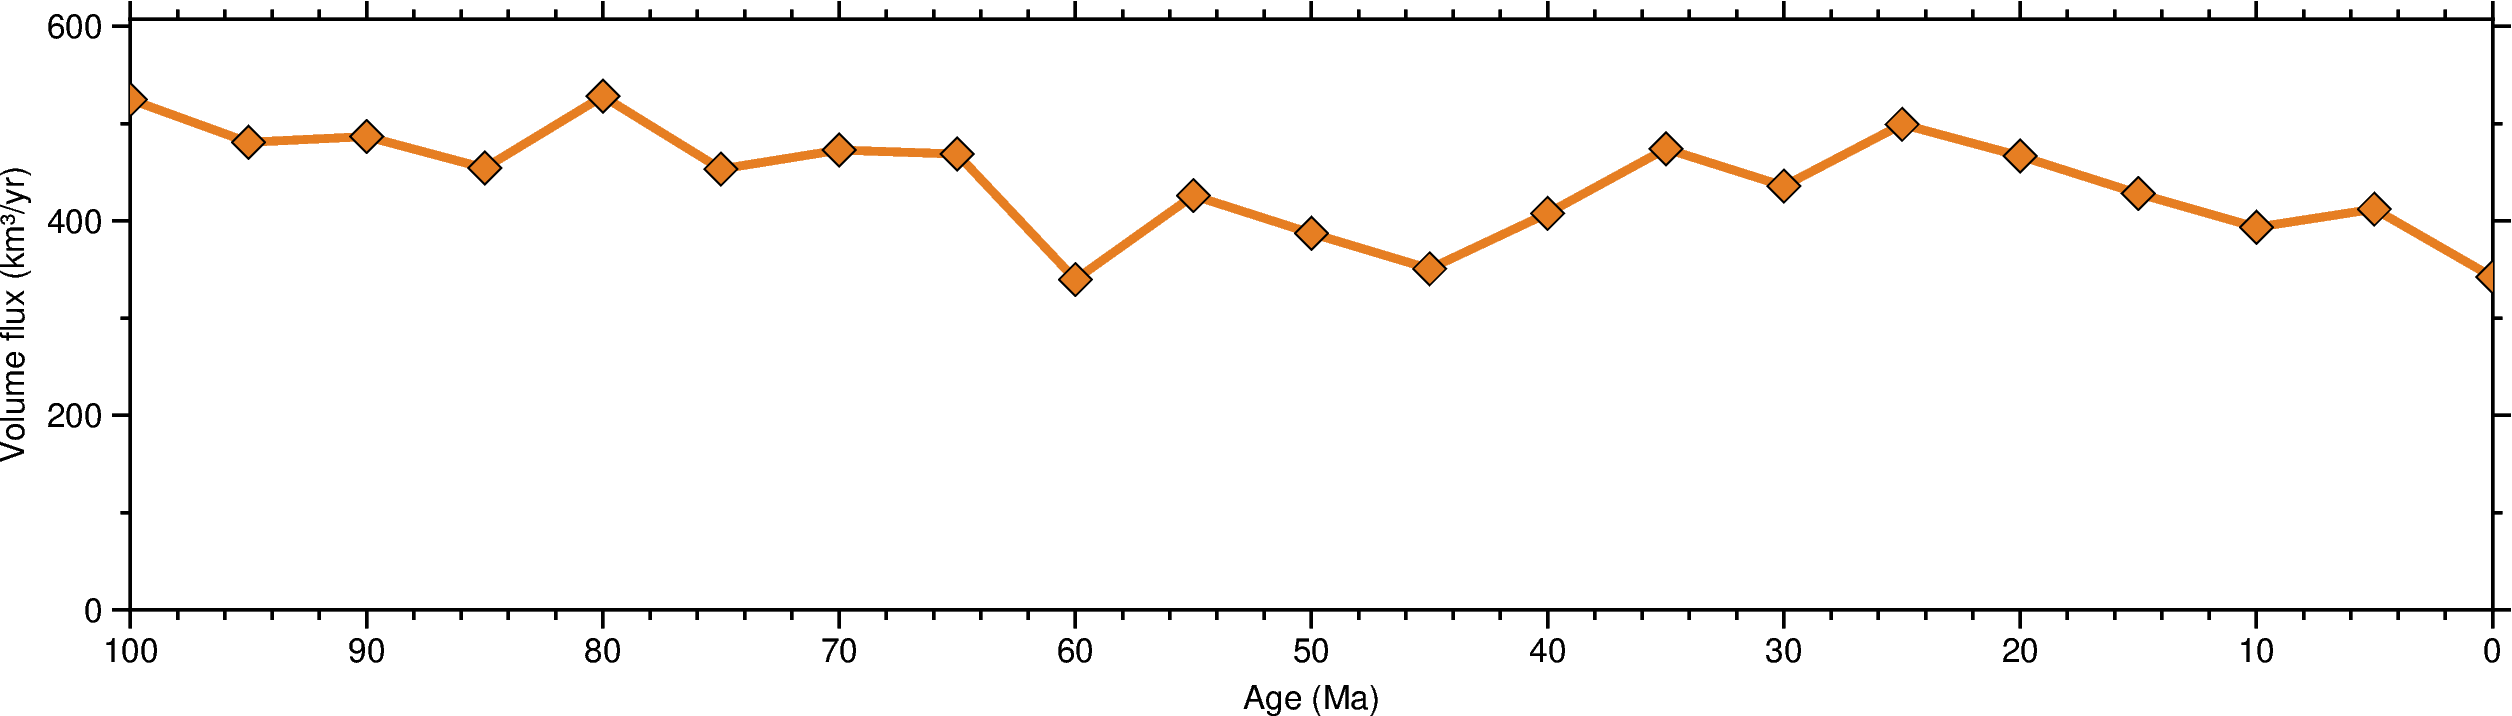

In [7]:
# Four separate pyGMT figures (house-style: one Figure per panel — no pygmt.subplot).

X_MIN, X_MAX = 0, FLUX_TIME_MAX_MA    # older to the left

# Panel 1 — trench length
fig = pygmt.Figure()
fig.basemap(region=[X_MIN, X_MAX,
                    0, float(flux_df["total_trench_length_km"].max()) * 1.1 / 1000],
            projection="X-20c/5c",
            frame=["Wsne+t" + f"Subducted-slab flux inventory  ({MODEL_NAME})  "
                   f"{FLUX_TIME_MIN_MA}-{FLUX_TIME_MAX_MA} Ma",
                   "xaf", "yaf+lTrench length (×1000 km)"])
fig.plot(x=flux_df["time_ma"], y=flux_df["total_trench_length_km"] / 1000,
         pen="2p,#2c3e50")
fig.plot(x=flux_df["time_ma"], y=flux_df["total_trench_length_km"] / 1000,
         style="c0.25c", fill="#2c3e50", pen="0.3p,black")
fig.show(width=1000)

# Panel 2 — mean slab age
fig = pygmt.Figure()
y_range = flux_df["mean_slab_age_ma"].dropna()
fig.basemap(region=[X_MIN, X_MAX, float(y_range.min()) - 5, float(y_range.max()) + 5],
            projection="X-20c/5c",
            frame=["Wsne", "xaf", "yaf+lMean subducting slab age (Ma)"])
fig.plot(x=flux_df["time_ma"], y=flux_df["mean_slab_age_ma"], pen="2p,#c0392b")
fig.plot(x=flux_df["time_ma"], y=flux_df["mean_slab_age_ma"],
         style="s0.25c", fill="#c0392b", pen="0.3p,black")
fig.show(width=1000)

# Panel 3 — area flux
fig = pygmt.Figure()
fig.basemap(region=[X_MIN, X_MAX, 0, float(flux_df["total_area_flux_km2_yr"].max()) * 1.15],
            projection="X-20c/5c",
            frame=["Wsne", "xaf", "yaf+lArea flux (km²/yr)"])
fig.plot(x=flux_df["time_ma"], y=flux_df["total_area_flux_km2_yr"],
         pen="2p,#27ae60")
fig.plot(x=flux_df["time_ma"], y=flux_df["total_area_flux_km2_yr"],
         style="t0.28c", fill="#27ae60", pen="0.3p,black")
fig.show(width=1000)

# Panel 4 — volume flux
fig = pygmt.Figure()
fig.basemap(region=[X_MIN, X_MAX, 0, float(flux_df["total_vol_flux_km3_yr"].max()) * 1.15],
            projection="X-20c/5c",
            frame=["WSne", "xa10f2+lAge (Ma)", "yaf+lVolume flux (km³/yr)"])
fig.plot(x=flux_df["time_ma"], y=flux_df["total_vol_flux_km3_yr"],
         pen="2p,#e67e22")
fig.plot(x=flux_df["time_ma"], y=flux_df["total_vol_flux_km3_yr"],
         style="d0.28c", fill="#e67e22", pen="0.3p,black")
fig.show(width=1000)


### How to read the flux plots

- **Trench length** (panel 1) — ~40,000 km present-day, slightly higher at 60-70 Ma (peak Pacific-basin expansion), lower during the mid-Cretaceous "quiet interval" of continental breakup.
- **Mean slab age** (panel 2) — ~70-80 Ma today. Younger in the mid-Cretaceous (peak spreading = younger seafloor being subducted), older during the Cenozoic (accumulation of old cold slabs at western Pacific).
- **Area flux** (panel 3) — ~3 km²/yr today (Parsons 1981 canonical value). Higher (~4-5 km²/yr) in the mid-Cretaceous during the "superplume" high-spreading interval.
- **Volume flux** (panel 4) — the product. Peaks when both trench length AND slab thickness are large, i.e. old cold slab subducting through long trenches. Cenozoic volume flux tends to be higher than mid-Cretaceous despite lower area flux, because slabs are older/thicker.

**Sanity check**: present-day (0 Ma) total area flux should be ~2.5-3.5 km²/yr. If it's dramatically different, either the SZ filter or the convergence-rate sign convention is off. Watch out for **PTT tessellation artefacts** at ridge-transform intersections (see T20 for a similar filter) — some spurious high-convergence points can bias the mean upward.

**Caveats**

- We haven't distinguished continent-continent collision zones (which get flagged as convergent but aren't oceanic subduction) from true oceanic-plate subduction. A real inventory would filter overriding-plate polygon type.
- Volume flux uses only the thermal-boundary-layer thickness for the mantle lithosphere; a real subducted mass calculation would also include entrained sediment (T67 does this).


## Extend this

- **Add sediment flux.** Sample the Dutkiewicz et al. (2017) sediment-thickness field at each SZ point, add to volume flux. Dominant term in some low-slab-age arcs.
- **Add carbonate/water flux.** T67 (carbonate-platform degassing) shows the workflow using Ben Mather's `carbonate-platform-degassing` engine. Or use the Dixon et al. water-subduction proxy grid.
- **Filter by tectonic setting.** Split fluxes by overriding plate type — continental (Andean/Sunda type) vs oceanic (Marianas/Tonga type). Different geochemical signature comes out of each.
- **Extend to full Phanerozoic.** Z22 covers 0-410 Ma; loop with `FLUX_TIME_MAX_MA=400` for a Phanerozoic story. Watch for the mid-Cretaceous superplume signature and the Late Paleozoic Pangaea assembly slowdown.
- **Compare with published series.** East, Domeier & Torsvik (2020, *EPSL*) and Muller et al. (2016, *Ann. Rev. E. Planet Sci.*) both publish Phanerozoic subduction-flux compilations for cross-checking.

## Related notebooks

- **T20** — MOR velocity magnitude via PTT `tessellate_mid_ocean_ridges`. Same tessellation API, complementary spreading-flux inventory.
- **T22** — distance-to-subduction-zone from Wu 2023 zircons.
- **T67** — carbonate-platform degassing (Ben Mather engine) — takes T66's SZ points and adds a CO₂ degassing calculation.

## Sources

- Parsons, B. (1981). The rates of plate creation and consumption. *Geophysical Journal of the Royal Astronomical Society* 67(2), 437-448.
- Stein, C.A. & Stein, S. (1992). A model for the global variation in oceanic depth and heat flow with lithospheric age. *Nature* 359, 123-129.
- East, M., Müller, R.D., Williams, S., Zahirovic, S. & Heine, C. (2020). Subduction history reveals Cretaceous slab superflux as a possible cause for the mid-Cretaceous plume pulse and superswell events. *Gondwana Research* 79, 125-139. doi:10.1016/j.gr.2019.09.001.
- Müller, R.D., Seton, M., Zahirovic, S., Williams, S.E., Matthews, K.J., Wright, N.M. et al. (2016). Ocean basin evolution and global-scale plate reorganization events since Pangea breakup. *Annual Review of Earth and Planetary Sciences* 44, 107-138.
- Dutkiewicz, A., Müller, R.D., Wang, X., O'Callaghan, S., Cannon, J. & Wright, N.M. (2017). Predicting sediment thickness on vanished ocean crust since 200 Ma. *Geochemistry, Geophysics, Geosystems* 18, 4586-4603.
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Fox, P. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9(2), 371-383. doi:10.1002/gdj3.146.
